<a href="https://colab.research.google.com/github/Trixxzer/PrajwolShrestha_2418111_AIML_Worksheets/blob/main/2418111_Prajwol_Shrestha_Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake News Detection Using RNN, LSTM and Word2Vec/GloVe Embeddings

**Module:** Artificial Intelligence and Machine Learning (6CS012)  
**Assessment Part:** Part III – Language Task  
**Dataset:** True vs Fake News Dataset  
**Task:** Binary text classification (`true` vs `fake`)

This notebook follows the final portfolio language task requirements: text loading, cleaning, tokenization, sequence padding, RNN model, LSTM model, LSTM with pretrained embeddings, evaluation, error analysis and real-time prediction GUI.

## 0. Runtime Setup

Run this notebook in **Google Colab with GPU enabled**. Upload `10.True vs. Fake News Dataset(1).zip` to Colab, or keep it in the same working directory.

In [ ]:
# If running on Colab, these commands help ensure required NLP libraries are available.
# Run once if any import below fails.
# !pip -q install nltk gensim wordcloud gradio

import os, re, zipfile, time, random, string
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks, optimizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_recall_fscore_support

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load and Extract Dataset

The dataset is loaded from CSV as required. The expected columns are `text` and `label`.

In [ ]:
from pathlib import Path
import shutil
import pandas as pd
from google.colab import drive

# Your dataset folder in Google Drive
DRIVE_DATASET_DIR = Path('/content/drive/MyDrive/AI-ML/ASSESSMENT DATASET/True vs. Fake News Dataset')

# Destination folder inside Colab content
CONTENT_DATASET_DIR = Path('/content/True vs. Fake News Dataset')

# Check Drive folder exists
if not DRIVE_DATASET_DIR.exists():
    raise FileNotFoundError(
        f'Drive dataset folder not found: {DRIVE_DATASET_DIR}\n'
        'Check the folder name/path in Google Drive.'
    )

# Copy folder from Drive to /content
if CONTENT_DATASET_DIR.exists():
    shutil.rmtree(CONTENT_DATASET_DIR)

shutil.copytree(DRIVE_DATASET_DIR, CONTENT_DATASET_DIR)

print('Dataset copied to:', CONTENT_DATASET_DIR)

# Find CSV file inside /content folder
csv_files = list(CONTENT_DATASET_DIR.rglob('*.csv'))

if not csv_files:
    raise FileNotFoundError(
        f'No CSV file found inside: {CONTENT_DATASET_DIR}'
    )

csv_path = csv_files[0]

# Load dataset
df = pd.read_csv(csv_path)

print('CSV path:', csv_path)
print('Shape:', df.shape)

display(df.head())
df.info()

Dataset copied to: /content/True vs. Fake News Dataset
CSV path: /content/True vs. Fake News Dataset/10.True vs. Fake News Dataset/truevsfakenews.csv
Shape: (20000, 2)


,text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,true
1,Women should get as far away from Oklahoma as ...,fake
2,Another huge crowd of Americans tuned in last ...,fake
3,Donald Trump is desperate to stop the investig...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",true


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    20000 non-null  object
 1   label   20000 non-null  object
dtypes: object(2)
memory usage: 312.6+ KB


## 2. Data Understanding and Basic Analysis

This section checks data size, label distribution, missing values, duplicate records and text length variation.

Columns: ['text', 'label']

Missing values:


,0
text,0
label,0



Label distribution:


,count
label,
true,10000
fake,10000



Duplicate text records: 54


,word_count_raw
count,20000.000000
mean,426.099800
std,245.779755
min,0.000000
25%,307.000000
50%,397.500000
75%,527.000000
max,7033.000000


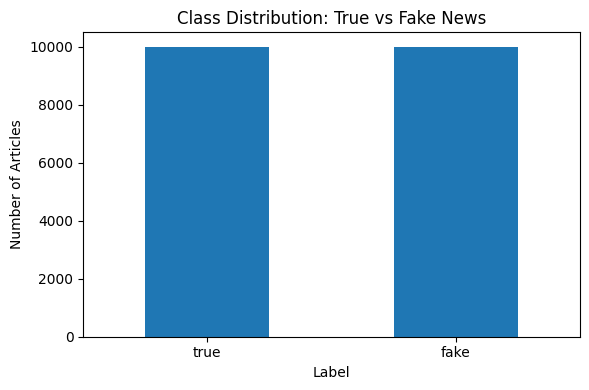

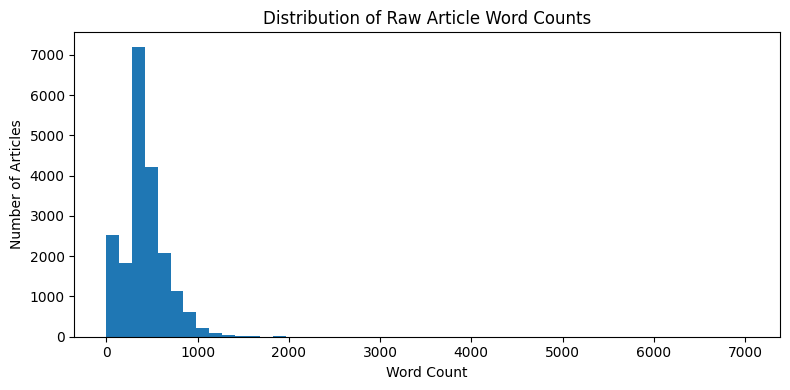

In [ ]:
print('Columns:', df.columns.tolist())
print('\nMissing values:')
display(df.isna().sum())

print('\nLabel distribution:')
display(df['label'].value_counts())

print('\nDuplicate text records:', df.duplicated(subset=['text']).sum())

df['word_count_raw'] = df['text'].astype(str).str.split().str.len()
display(df['word_count_raw'].describe())

plt.figure(figsize=(6,4))
df['label'].value_counts().plot(kind='bar')
plt.title('Class Distribution: True vs Fake News')
plt.xlabel('Label')
plt.ylabel('Number of Articles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.hist(df['word_count_raw'], bins=50)
plt.title('Distribution of Raw Article Word Counts')
plt.xlabel('Word Count')
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.show()

## 3. Text Cleaning

Required preprocessing steps:
- Lowercase text
- Remove URLs, mentions, hashtags, numbers and special characters
- Handle contractions
- Remove stopwords
- Lemmatise words

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

CONTRACTIONS = {
    "can't": "cannot", "won't": "will not", "n't": " not", "'re": " are", "'s": " is",
    "'d": " would", "'ll": " will", "'t": " not", "'ve": " have", "'m": " am",
    "don’t": "do not", "can’t": "cannot", "won’t": "will not", "isn’t": "is not",
    "aren’t": "are not", "wasn’t": "was not", "weren’t": "were not"
}

def expand_contractions(text):
    text = str(text)
    for contraction, expanded in CONTRACTIONS.items():
        text = text.replace(contraction, expanded)
    return text

def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r'http\S+|www\S+', ' ', text)      # URLs
    text = re.sub(r'@\w+', ' ', text)                # mentions
    text = re.sub(r'#', ' ', text)                   # hashtag symbol
    text = re.sub(r'\d+', ' ', text)                 # numbers
    text = re.sub(r'[^a-z\s]', ' ', text)            # special characters/punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in STOPWORDS and len(w) > 2]
    return ' '.join(tokens)

# Remove exact duplicate articles before modelling
df_clean = df.drop_duplicates(subset=['text']).copy()
df_clean = df_clean.dropna(subset=['text', 'label']).copy()

df_clean['clean_text'] = df_clean['text'].apply(clean_text)
df_clean = df_clean[df_clean['clean_text'].str.len() > 0].copy()
df_clean['word_count_clean'] = df_clean['clean_text'].str.split().str.len()

print('Cleaned shape:', df_clean.shape)
display(df_clean[['text', 'clean_text', 'label', 'word_count_clean']].head())
display(df_clean['word_count_clean'].describe())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Cleaned shape: (19944, 5)


,text,clean_text,label,word_count_clean
0,WASHINGTON (Reuters) - The Republican and Demo...,washington reuters republican democratic leade...,true,160
1,Women should get as far away from Oklahoma as ...,woman get far away oklahoma soon possible chri...,fake,274
2,Another huge crowd of Americans tuned in last ...,another huge crowd american tuned last week re...,fake,214
3,Donald Trump is desperate to stop the investig...,donald trump desperate stop investigation dirt...,fake,203
4,"(Reuters) - Planned Parenthood, the U.S. medic...",reuters planned parenthood medical service pro...,true,214


,word_count_clean
count,19944.000000
mean,239.341456
std,141.855597
min,15.000000
25%,167.000000
50%,222.000000
75%,291.000000
max,4753.000000


## 4. Visualise Cleaned Data

The assessment asks for cleaned data visualisation. This notebook shows the most frequent words and optionally a word cloud if the package is available.

,word,count
0,trump,100754
1,said,61668
2,president,31811
3,republican,31350
4,would,30244
5,state,29339
6,people,21211
7,donald,20633
8,one,19181
9,house,19060


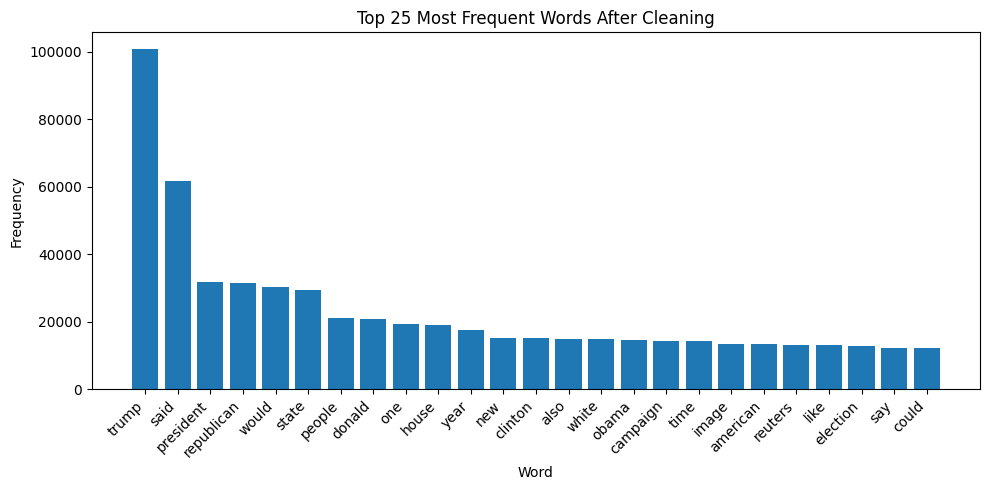

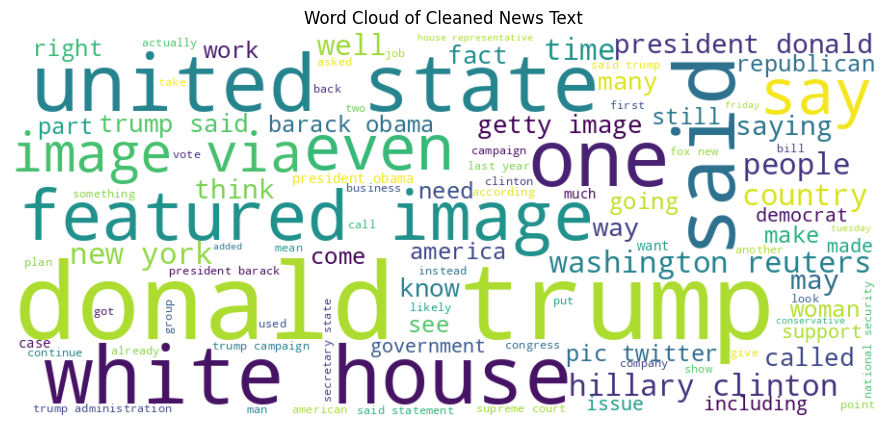

In [ ]:
all_words = ' '.join(df_clean['clean_text']).split()
word_freq = Counter(all_words).most_common(25)
freq_df = pd.DataFrame(word_freq, columns=['word', 'count'])
display(freq_df)

plt.figure(figsize=(10,5))
plt.bar(freq_df['word'], freq_df['count'])
plt.title('Top 25 Most Frequent Words After Cleaning')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

try:
    from wordcloud import WordCloud
    wc = WordCloud(width=900, height=400, background_color='white', max_words=100).generate(' '.join(all_words))
    plt.figure(figsize=(12,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Cleaned News Text')
    plt.show()
except Exception as e:
    print('WordCloud skipped. Install with: !pip install wordcloud. Error:', e)

## 5. Train-Test Split, Tokenization and Percentile-Based Padding

Requirement:
- 80% training and 20% testing split
- Keras Tokenizer
- Padding to uniform length
- Percentile-based padding to avoid excessively long sequences

In [ ]:
label_map = {'fake': 0, 'true': 1}
df_clean['label_num'] = df_clean['label'].str.lower().map(label_map)
if df_clean['label_num'].isna().any():
    raise ValueError('Unexpected labels found. Check label values before continuing.')

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df_clean['clean_text'].values,
    df_clean['label_num'].values,
    test_size=0.20,
    random_state=SEED,
    stratify=df_clean['label_num'].values
)

MAX_WORDS = 30000
EMBEDDING_DIM = 50

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

lengths = [len(seq) for seq in X_train_seq]
MAX_LEN = int(np.percentile(lengths, 95))
MAX_LEN = max(MAX_LEN, 20)
print('95th percentile sequence length:', MAX_LEN)

X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print('Vocabulary size used:', vocab_size)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

95th percentile sequence length: 491
Vocabulary size used: 30000
Train shape: (15955, 491) Test shape: (3989, 491)


## 6. Helper Functions for Model Training and Evaluation

In [ ]:
def get_callbacks(model_name, patience=3):
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True),
        callbacks.ModelCheckpoint(f'{model_name}.keras', monitor='val_loss', save_best_only=True)
    ]

def plot_history(history, title):
    hist = pd.DataFrame(history.history)
    plt.figure(figsize=(8,5))
    plt.plot(hist['loss'], label='Training Loss')
    plt.plot(hist['val_loss'], label='Validation Loss')
    plt.title(title + ' - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(hist['accuracy'], label='Training Accuracy')
    plt.plot(hist['val_accuracy'], label='Validation Accuracy')
    plt.title(title + ' - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def evaluate_binary_model(model, X_test, y_test, model_name):
    start = time.time()
    probs = model.predict(X_test, verbose=1).ravel()
    pred = (probs >= 0.5).astype(int)
    elapsed = time.time() - start

    acc = accuracy_score(y_test, pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, pred, average='weighted', zero_division=0)
    print(f'\n{model_name} Evaluation')
    print(f'Accuracy: {acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-score: {f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_test, pred, target_names=['fake', 'true'], zero_division=0))

    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['fake', 'true'])
    fig, ax = plt.subplots(figsize=(5,5))
    disp.plot(ax=ax, cmap=None, colorbar=False)
    plt.title(model_name + ' Confusion Matrix')
    plt.show()

    return {'model': model_name, 'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'prediction_time_sec': elapsed, 'probs': probs, 'pred': pred}

training_results = []
eval_outputs = {}

## 7. Model 1 – Simple RNN with Trainable Embedding Layer

In [ ]:
def build_simple_rnn(vocab_size, embedding_dim, max_len):
    model = models.Sequential(name='Simple_RNN_Trainable_Embedding')
    model.add(layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len))
    model.add(layers.SimpleRNN(64, dropout=0.2, recurrent_dropout=0.0))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

rnn_model = build_simple_rnn(vocab_size, EMBEDDING_DIM, MAX_LEN)
rnn_model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'])
rnn_model.summary()

Model: "Simple_RNN_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.5125 - loss: 0.6947 - val_accuracy: 0.4983 - val_loss: 0.6869
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.5245 - loss: 0.6897 - val_accuracy: 0.5346 - val_loss: 0.6891
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.5359 - loss: 0.6759 - val_accuracy: 0.5349 - val_loss: 0.6823
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.5418 - loss: 0.6623 - val_accuracy: 0.5346 - val_loss: 0.6836
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.5432 - loss: 0.6577 - val_accuracy: 0.5318 - val_loss: 0.6909
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.5458 - loss: 0.6562 - val_accuracy: 0.5302 - val_loss: 0.6947
Simple RNN training time: 67.11 seconds


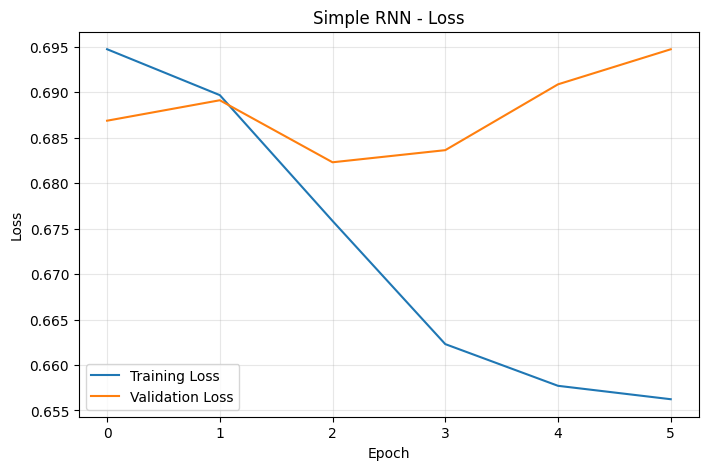

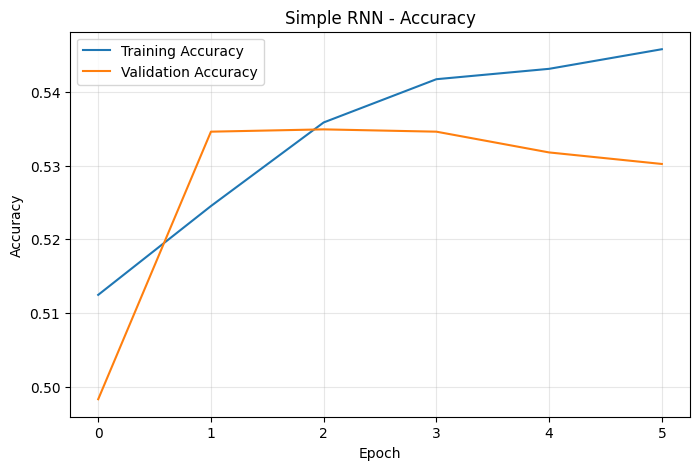

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step

Simple RNN Evaluation
Accuracy: 0.5375 | Precision: 0.6816 | Recall: 0.5375 | F1-score: 0.4218

Classification Report:
              precision    recall  f1-score   support

        fake       0.52      0.98      0.68      1999
        true       0.84      0.09      0.16      1990

    accuracy                           0.54      3989
   macro avg       0.68      0.54      0.42      3989
weighted avg       0.68      0.54      0.42      3989



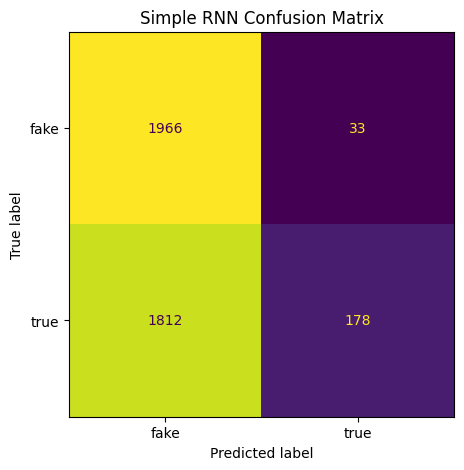

In [ ]:
EPOCHS = 20
BATCH_SIZE = 64

start_time = time.time()
rnn_history = rnn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('simple_rnn'),
    verbose=1
)
rnn_time = time.time() - start_time
print(f'Simple RNN training time: {rnn_time:.2f} seconds')
plot_history(rnn_history, 'Simple RNN')

out = evaluate_binary_model(rnn_model, X_test, y_test, 'Simple RNN')
eval_outputs['Simple RNN'] = out
training_results.append({k:v for k,v in out.items() if k not in ['probs','pred']} | {'training_time_sec': rnn_time})

## 8. Model 2 – LSTM with Trainable Embedding Layer

In [ ]:
def build_lstm(vocab_size, embedding_dim, max_len):
    model = models.Sequential(name='LSTM_Trainable_Embedding')
    model.add(layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len))
    model.add(layers.LSTM(64, dropout=0.2, recurrent_dropout=0.0))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

lstm_model = build_lstm(vocab_size, EMBEDDING_DIM, MAX_LEN)
lstm_model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.5276 - loss: 0.6885 - val_accuracy: 0.5359 - val_loss: 0.6781
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5331 - loss: 0.6732 - val_accuracy: 0.5368 - val_loss: 0.6748
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.5500 - loss: 0.6627 - val_accuracy: 0.5525 - val_loss: 0.6670
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.5456 - loss: 0.6688 - val_accuracy: 0.5393 - val_loss: 0.6934
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5865 - loss: 0.6498 - val_accuracy: 0.8941 - val_loss: 0.4647
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9629 - loss: 0.1531 - val_accuracy: 0.9875 - val_loss: 0.0658
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9916 - loss: 0.0507 - val_accuracy: 0.9856 - val_loss: 0.0717
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9806 - loss: 0.0777 - val_acc

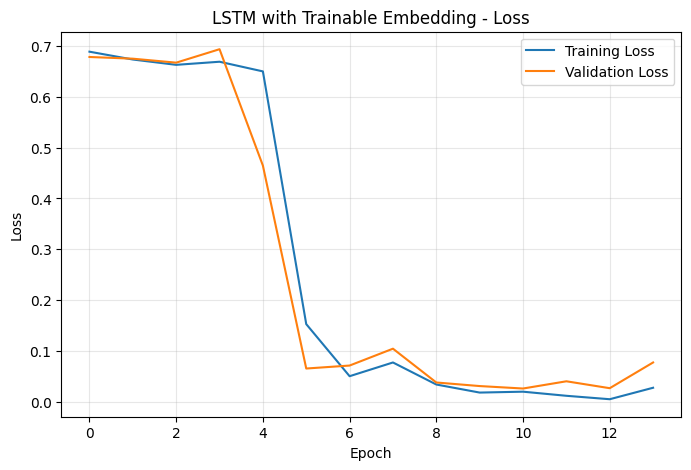

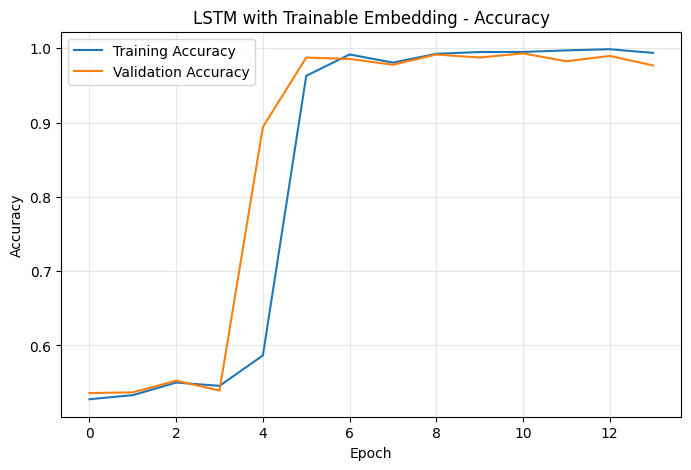

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

LSTM Trainable Embedding Evaluation
Accuracy: 0.9935 | Precision: 0.9935 | Recall: 0.9935 | F1-score: 0.9935

Classification Report:
              precision    recall  f1-score   support

        fake       1.00      0.99      0.99      1999
        true       0.99      1.00      0.99      1990

    accuracy                           0.99      3989
   macro avg       0.99      0.99      0.99      3989
weighted avg       0.99      0.99      0.99      3989



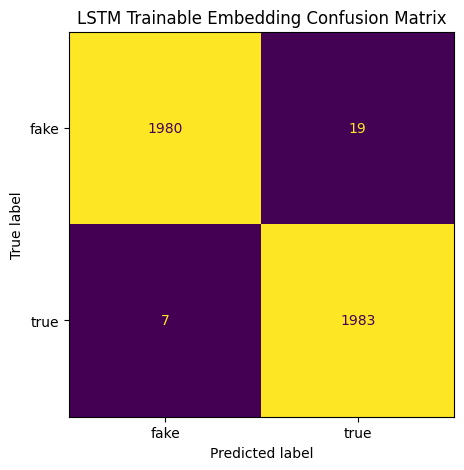

In [ ]:
start_time = time.time()
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('lstm_trainable'),
    verbose=1
)
lstm_time = time.time() - start_time
print(f'LSTM training time: {lstm_time:.2f} seconds')
plot_history(lstm_history, 'LSTM with Trainable Embedding')

out = evaluate_binary_model(lstm_model, X_test, y_test, 'LSTM Trainable Embedding')
eval_outputs['LSTM Trainable Embedding'] = out
training_results.append({k:v for k,v in out.items() if k not in ['probs','pred']} | {'training_time_sec': lstm_time})

## 9. Model 3 – LSTM with Pretrained Word2Vec/GloVe Embeddings

The assessment appendix suggests using `gensim` to load pretrained embeddings. This notebook uses `glove-wiki-gigaword-50` from `gensim.downloader`, which provides 50-dimensional pretrained word vectors.

In [ ]:
try:
    # Install gensim if not already installed
    try:
        import gensim.downloader as api
    except ImportError:
        !pip install gensim
        import gensim.downloader as api
except Exception as e:
    raise ImportError('Install gensim first using: !pip install gensim. Original error: ' + str(e))

try:
    embedding_model = api.load('glove-wiki-gigaword-50')
    print('Loaded pretrained glove-wiki-gigaword-50 embeddings.')
except Exception as e:
    raise RuntimeError('Could not download pretrained embeddings. Check internet connection in Colab. Error: ' + str(e))

embedding_dim = 50
word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, embedding_dim))
found_words = 0

for word, i in word_index.items():
    if i >= vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found_words += 1

print(f'Embedding coverage: {found_words}/{vocab_size} = {found_words/vocab_size:.2%}')

Loaded pretrained glove-wiki-gigaword-50 embeddings.
Embedding coverage: 28322/30000 = 94.41%


In [ ]:
def build_lstm_pretrained(vocab_size, embedding_dim, max_len, embedding_matrix):
    model = models.Sequential(name='LSTM_Pretrained_GloVe_Embedding')
    model.add(layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=True
    ))
    model.add(layers.LSTM(64, dropout=0.2, recurrent_dropout=0.0))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

pretrained_lstm_model = build_lstm_pretrained(vocab_size, embedding_dim, MAX_LEN, embedding_matrix)
pretrained_lstm_model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'])
pretrained_lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM_Pretrained_GloVe_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,500,000 (5.72 MB)

 Trainable params: 1,500,000 (5.72 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.5521 - loss: 0.6873 - val_accuracy: 0.5954 - val_loss: 0.6311
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.7414 - loss: 0.5318 - val_accuracy: 0.5368 - val_loss: 0.6632
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.6488 - loss: 0.6004 - val_accuracy: 0.5744 - val_loss: 0.6602
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8429 - loss: 0.3458 - val_accuracy: 0.9756 - val_loss: 0.0930
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9781 - loss: 0.0882 - val_accuracy: 0.9922 - val_loss: 0.0324
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9935 - loss: 0.0286 - val_accuracy: 0.9959 - val_loss: 0.0235
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9969 - loss: 0.0127 - val_accuracy: 0.9972 - val_loss: 0.0186
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9981 - loss: 0.0092 - val_ac

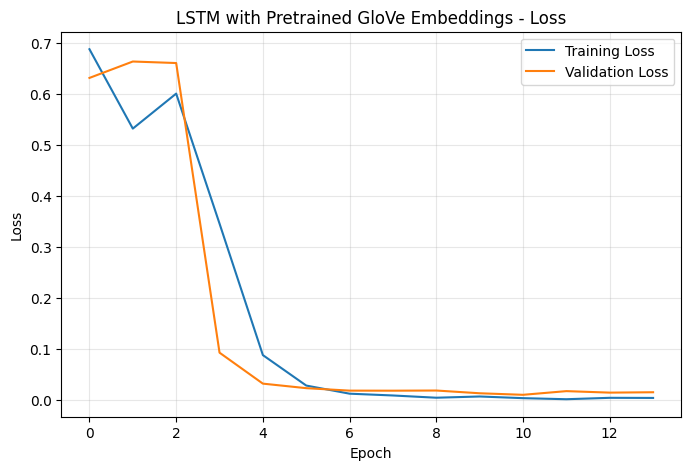

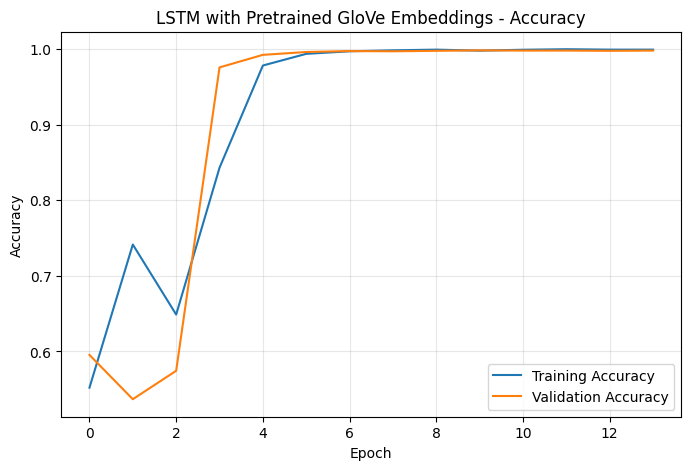

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

LSTM Pretrained GloVe Evaluation
Accuracy: 0.9997 | Precision: 0.9997 | Recall: 0.9997 | F1-score: 0.9997

Classification Report:
              precision    recall  f1-score   support

        fake       1.00      1.00      1.00      1999
        true       1.00      1.00      1.00      1990

    accuracy                           1.00      3989
   macro avg       1.00      1.00      1.00      3989
weighted avg       1.00      1.00      1.00      3989



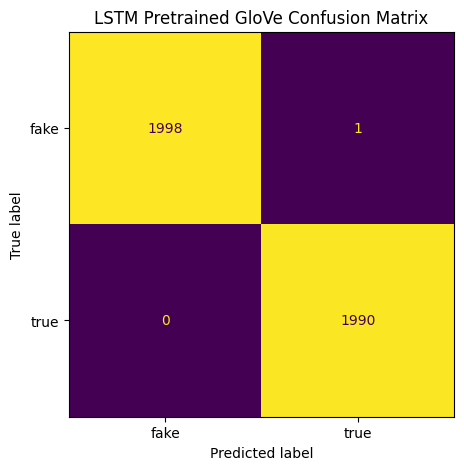

In [ ]:
start_time = time.time()
pretrained_history = pretrained_lstm_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('lstm_pretrained_glove'),
    verbose=1
)
pretrained_time = time.time() - start_time
print(f'LSTM with pretrained embeddings training time: {pretrained_time:.2f} seconds')
plot_history(pretrained_history, 'LSTM with Pretrained GloVe Embeddings')

out = evaluate_binary_model(pretrained_lstm_model, X_test, y_test, 'LSTM Pretrained GloVe')
eval_outputs['LSTM Pretrained GloVe'] = out
training_results.append({k:v for k,v in out.items() if k not in ['probs','pred']} | {'training_time_sec': pretrained_time})

## 10. Model Comparison

Compare RNN, LSTM and LSTM with pretrained embeddings using accuracy, precision, recall, F1-score, loss curves and training time.

,model,accuracy,precision,recall,f1,prediction_time_sec,training_time_sec
4,LSTM Pretrained GloVe,0.999749,0.999749,0.999749,0.999749,1.426109,91.448574
2,LSTM Trainable Embedding,0.993482,0.993500,0.993482,0.993482,1.417413,82.356071
3,LSTM Pretrained GloVe,0.949110,0.949341,0.949110,0.949105,1.670381,49.603710
1,Simple RNN,0.537478,0.681627,0.537478,0.421773,1.913812,67.114410
0,LSTM Trainable Embedding,0.537227,0.681186,0.537227,0.421297,1.596852,28.188974


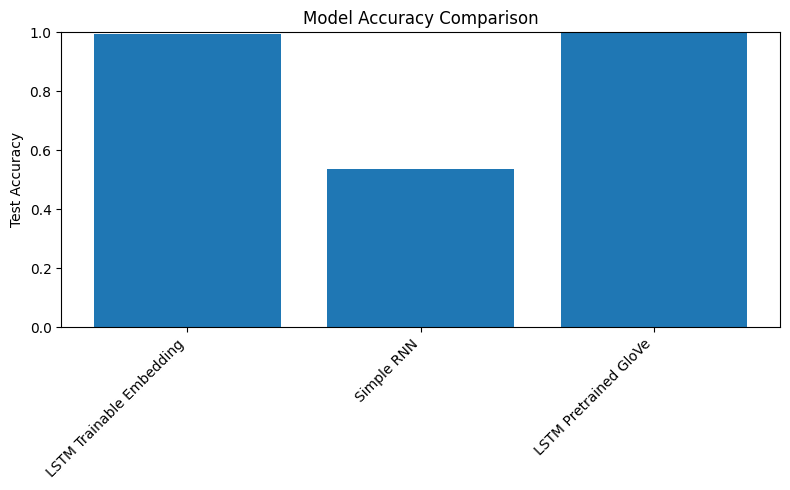

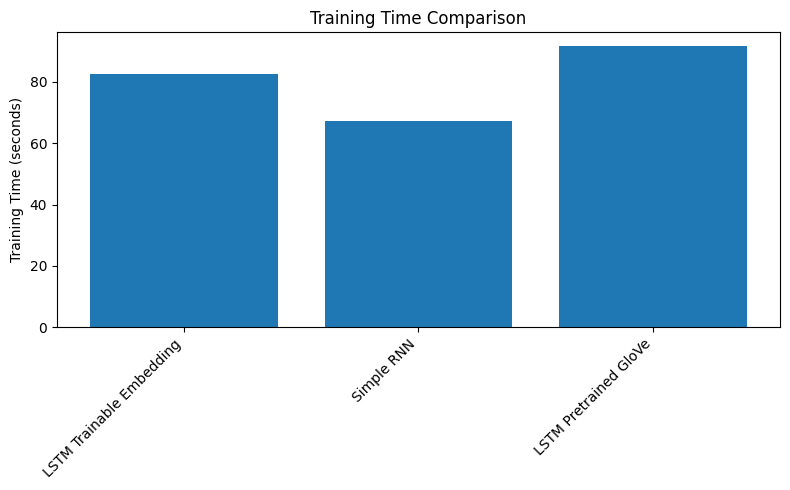

In [ ]:
results_df = pd.DataFrame(training_results)
display(results_df.sort_values('f1', ascending=False))

plt.figure(figsize=(8,5))
plt.bar(results_df['model'], results_df['accuracy'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Test Accuracy')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.bar(results_df['model'], results_df['training_time_sec'])
plt.title('Training Time Comparison')
plt.ylabel('Training Time (seconds)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 11. Error Analysis

Required:
- Show 2–3 incorrect predictions
- Evaluate model complexity vs performance
- Explain possible reasons for errors
- Suggest improvements

In [ ]:
best_model_name = results_df.sort_values('f1', ascending=False).iloc[0]['model']
print('Best model by weighted F1-score:', best_model_name)

best_pred = eval_outputs[best_model_name]['pred']
mis_idx = np.where(best_pred != y_test)[0]
print('Number of misclassified examples:', len(mis_idx))

label_reverse = {0: 'fake', 1: 'true'}
for i, idx in enumerate(mis_idx[:3], start=1):
    original_text = X_test_text[idx]
    print('\n' + '='*80)
    print(f'Misclassified Example {i}')
    print('True label:', label_reverse[int(y_test[idx])])
    print('Predicted label:', label_reverse[int(best_pred[idx])])
    print('Text preview:', original_text[:800], '...')

print('\nPossible reasons for errors:')
print('- Some fake and true articles use similar political vocabulary and formal news style.')
print('- Very long articles are truncated by percentile-based padding, so some useful context may be removed.')
print('- Removing numbers and punctuation can remove signals such as dates, statistics or quoted evidence.')
print('- RNN/LSTM models may struggle with very long-range dependencies in long news articles.')

print('\nPotential improvements:')
print('- Tune sequence length, vocabulary size, batch size and learning rate.')
print('- Try Bidirectional LSTM/GRU or transformer-based models.')
print('- Use domain-specific embeddings or fine-tune embeddings.')
print('- Keep selected numerical/date features instead of removing all numbers.')

Best model by weighted F1-score: LSTM Pretrained GloVe
Number of misclassified examples: 1

Misclassified Example 1
True label: fake
Predicted label: true
Text preview: celebrated congressional black caucus member legend corrine brown would like american believe stealing hundred thousand dollar underpriveleged child district using money vacation daughter reason found guilty count fraud corruption black washington examiner partied nancy pelosi traveled air force one next president obama cast superdelegate vote hillary clinton february corrine brown federal court stealing scholarship money school child disgraced congresswoman attempted defend charge funneled hundred thousand dollar non profit charity one door education pocket former chief staff testified question longer whether guilty democrat brass would continually cozy congresswoman clearly corrupt beginning brown shrouded controversy shortly election federal election commission accused brown violating n ...

Possible reasons for erro

## 12. Real-Time Prediction GUI with Gradio

The assessment asks for a simple GUI as an extra challenge. This section creates a Gradio interface where users can enter news text and receive a true/fake prediction.

In [ ]:
# Run this cell in Colab. If gradio is missing, uncomment the next line.
# !pip -q install gradio

best_model_lookup = {
    'Simple RNN': rnn_model,
    'LSTM Trainable Embedding': lstm_model,
    'LSTM Pretrained GloVe': pretrained_lstm_model
}

def predict_news(text, selected_model_name):
    model = best_model_lookup[selected_model_name]

    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(
        seq,
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )

    prob_true = float(model.predict(padded, verbose=0)[0][0])

    label = 'true' if prob_true >= 0.5 else 'fake'
    confidence = prob_true if label == 'true' else 1 - prob_true

    return {
        label: confidence,
        ('fake' if label == 'true' else 'true'): 1 - confidence
    }


try:
    import gradio as gr

    demo = gr.Interface(
        fn=predict_news,
        inputs=[
            gr.Textbox(lines=8, label='Enter news article text'),
            gr.Dropdown(
                choices=list(best_model_lookup.keys()),
                value=best_model_name,
                label='Choose Model'
            )
        ],
        outputs=gr.Label(num_top_classes=2, label='Prediction'),
        title='Fake News Detection - Real-Time Prediction',
        description='Enter a news article and choose a trained model to predict whether the news is true or fake.'
    )

    demo.launch(share=True, debug=True)

except Exception as e:
    print('Gradio interface skipped. Install with !pip install gradio if needed. Error:', e)
    print(
        'Test prediction:',
        predict_news(
            'Government officials announced a new policy today after a press conference.',
            best_model_name
        )
    )

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://18a510d26683d87bf2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7863 <> https://18a510d26683d87bf2.gradio.live


## 13. Key Observations Template for Report

After running the notebook, write your own final discussion:

1. **RNN vs LSTM:** Compare final accuracy, F1-score and training time.
2. **Pretrained Embedding Impact:** Explain whether GloVe improved results over trainable embeddings.
3. **Computational Efficiency:** Compare model complexity and runtime.
4. **Overfitting/Underfitting:** Use the loss and accuracy curves to identify training behaviour.
5. **Error Analysis:** Discuss misclassified examples and likely reasons.
6. **Future Work:** Suggest transformer models, better preprocessing, hyperparameter tuning and stronger real-time deployment.